In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv(r'C:\BIT_Data_analyst\06_machine learning\07_lesson\entertainment_clean.csv')

In [2]:
df.head()

,name,books,tv_shows,video_games
0,Aaliyah,0.5,4.6,4.9
1,Abigail,0.0,4.5,4.8
2,Addison,0.5,4.5,5.0
3,Adeline,3.5,4.5,6.6
4,Alana,2.8,3.8,5.6


In [3]:
# keep only the numeric columns
X = df.iloc[:, 1:]
X.head()

,books,tv_shows,video_games
0,0.5,4.6,4.9
1,0.0,4.5,4.8
2,0.5,4.5,5.0
3,3.5,4.5,6.6
4,2.8,3.8,5.6


In [4]:
# import isolation forest from sklearn
from sklearn.ensemble import IsolationForest

In [5]:
# fit an isolation forest model with 2% of the data set as anomalies
model = IsolationForest(contamination=0.02)
model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [6]:
# view the anomaly scores
df['anomaly_scores'] = model.decision_function(X)
df.sort_values('anomaly_scores').head(10)

,name,books,tv_shows,video_games,anomaly_scores
110,Octavia,5.0,5.7,7.9,-0.025114
15,Avery,1.0,6.6,5.7,-0.018004
37,Elena,0.8,3.4,4.5,-0.007509
42,Elizabeth,0.0,4.5,4.3,0.000153
147,Zara,5.5,5.7,7.7,0.005836
29,Clementine,6.2,5.4,7.2,0.011253
58,Hailey,2.5,3.0,5.0,0.013634
148,Zoe,0.0,6.1,5.2,0.014380
19,Bianca,5.8,3.9,7.7,0.027163
129,Sofia,0.5,6.0,5.8,0.041373


In [7]:
# view the anomaly flags
df['anomaly'] = model.predict(X)
df.sort_values('anomaly_scores').head(10)

,name,books,tv_shows,video_games,anomaly_scores,anomaly
110,Octavia,5.0,5.7,7.9,-0.025114,-1
15,Avery,1.0,6.6,5.7,-0.018004,-1
37,Elena,0.8,3.4,4.5,-0.007509,-1
42,Elizabeth,0.0,4.5,4.3,0.000153,1
147,Zara,5.5,5.7,7.7,0.005836,1
29,Clementine,6.2,5.4,7.2,0.011253,1
58,Hailey,2.5,3.0,5.0,0.013634,1
148,Zoe,0.0,6.1,5.2,0.014380,1
19,Bianca,5.8,3.9,7.7,0.027163,1
129,Sofia,0.5,6.0,5.8,0.041373,1


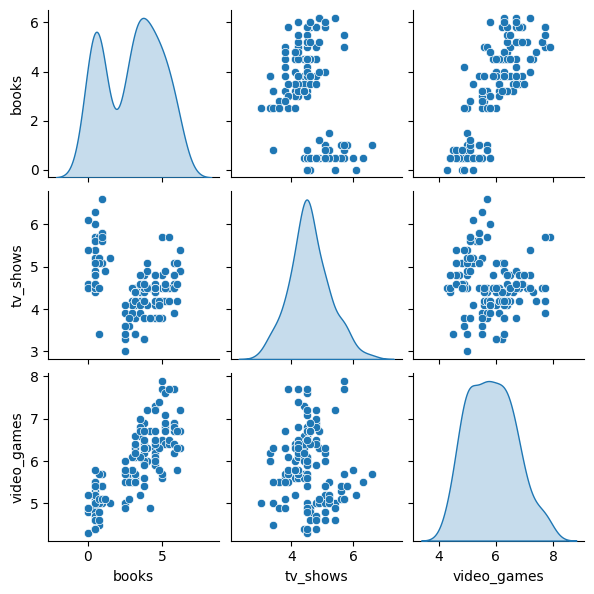

In [8]:
# view a pair plot of the original data set
import seaborn as sns
 
sns.pairplot(X, diag_kind='kde', height=2)

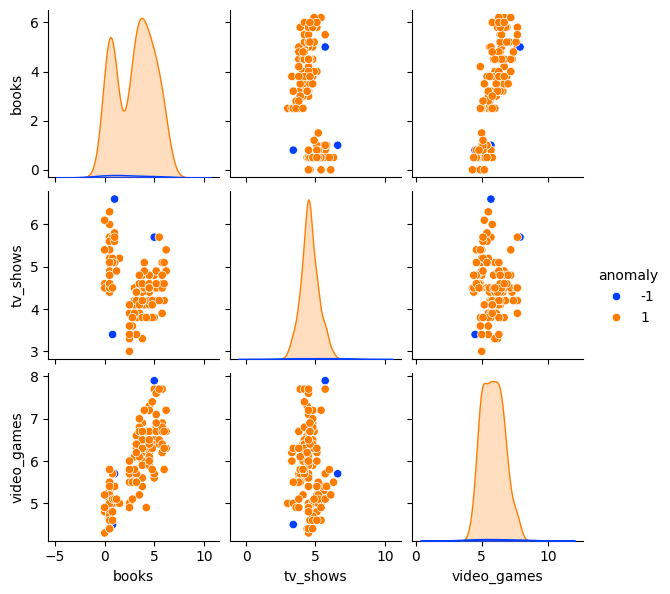

In [9]:
# overlay the isolation forest detected outliers
sns.pairplot(df.drop(columns='anomaly_scores'), hue='anomaly', palette='bright', height=2);

In [10]:
# update the model to flag 5% of rows as anomalies
model5 = IsolationForest(contamination=0.05, random_state=42)
model5.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [11]:
# view the anomaly scores
df['anomaly_scores_5'] = model5.decision_function(X)
df.sort_values('anomaly_scores_5').head(10)

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores_5
110,Octavia,5.0,5.7,7.9,-0.025114,-1,-0.040416
15,Avery,1.0,6.6,5.7,-0.018004,-1,-0.034753
37,Elena,0.8,3.4,4.5,-0.007509,-1,-0.034636
147,Zara,5.5,5.7,7.7,0.005836,1,-0.027916
148,Zoe,0.0,6.1,5.2,0.014380,1,-0.017880
29,Clementine,6.2,5.4,7.2,0.011253,1,-0.017022
58,Hailey,2.5,3.0,5.0,0.013634,1,-0.008977
42,Elizabeth,0.0,4.5,4.3,0.000153,1,-0.006022
109,Nora,0.5,6.3,5.5,0.055540,1,0.007360
19,Bianca,5.8,3.9,7.7,0.027163,1,0.008350


In [12]:
# view the anomaly flags
df['anomaly_5'] = model5.predict(X)
df.sort_values('anomaly_5').head(10)

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores_5,anomaly_5
15,Avery,1.0,6.6,5.7,-0.018004,-1,-0.034753,-1
29,Clementine,6.2,5.4,7.2,0.011253,1,-0.017022,-1
42,Elizabeth,0.0,4.5,4.3,0.000153,1,-0.006022,-1
37,Elena,0.8,3.4,4.5,-0.007509,-1,-0.034636,-1
58,Hailey,2.5,3.0,5.0,0.013634,1,-0.008977,-1
110,Octavia,5.0,5.7,7.9,-0.025114,-1,-0.040416,-1
147,Zara,5.5,5.7,7.7,0.005836,1,-0.027916,-1
148,Zoe,0.0,6.1,5.2,0.014380,1,-0.017880,-1
7,Amara,3.2,4.5,5.6,0.202878,1,0.175484,1
8,Amelia,0.0,4.6,4.9,0.110286,1,0.080896,1


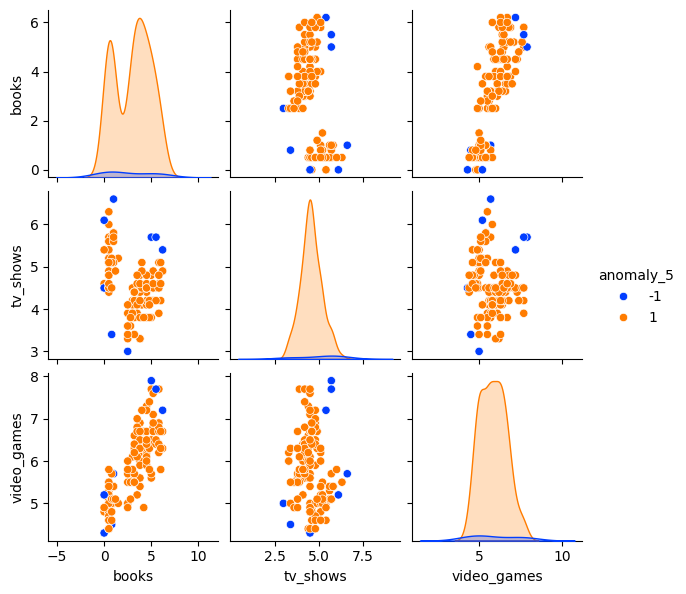

In [13]:
# overlay the isolation forest detected outliers
sns.pairplot(df.drop(columns=['anomaly_scores', 'anomaly', 'anomaly_scores_5']), hue='anomaly_5', palette='bright', height=2);

In [14]:
# dbscan function (copied from clustering section) to find a good eps + min_samples combo
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
 
def tune_dbscan(data):
 
    results = []
 
    # define a range of eps and min_samples values to loop through
    eps_values = np.arange(.1, 2, .1)
    min_samples_values = np.arange(2, 10, 1)
 
    # loop through the combinations of eps and min_samples
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            dbscan.fit(data)
            labels = dbscan.labels_
 
            # count the number of clusters (excluding noise points labeled as -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
 
            # count the number of noise points (labeled as -1)
            n_noise = list(labels).count(-1)
 
            # calculate the silhouette score (excluding noise points)
            if n_clusters > 1:  # silhouette score requires at least 2 clusters
                silhouette = silhouette_score(data, labels, metric='euclidean', sample_size=None)
            else:
                silhouette = None
 
            results.append([eps, min_samples, n_clusters, n_noise, silhouette])
 
    # put the results in a dataframe
    dbscan_results = pd.DataFrame(results, columns=["Eps", "Min Samples", "Number of Clusters",
                                                    "Number of Noise Points", "Silhouette Score"])
    return dbscan_results

In [15]:
# view the results on the original data
dbscan_results = tune_dbscan(X)
dbscan_results.head(10)

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,0.1,2,12,124,-0.438782
1,0.1,3,2,144,-0.483479
2,0.1,4,0,150,NaN
3,0.1,5,0,150,NaN
4,0.1,6,0,150,NaN
5,0.1,7,0,150,NaN
6,0.1,8,0,150,NaN
7,0.1,9,0,150,NaN
8,0.2,2,25,87,-0.184281
9,0.2,3,7,123,-0.418327


In [16]:
# top silhouette scores
dbscan_results.sort_values(by='Silhouette Score', ascending=False).head(10)

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
109,1.4,7,2,0,0.628673
110,1.4,8,2,0,0.628673
111,1.4,9,2,0,0.628673
112,1.5,2,2,0,0.628673
113,1.5,3,2,0,0.628673
114,1.5,4,2,0,0.628673
115,1.5,5,2,0,0.628673
116,1.5,6,2,0,0.628673
117,1.5,7,2,0,0.628673
118,1.5,8,2,0,0.628673


In [17]:
# return one eps + min_samples combo for each silhouette score
(dbscan_results.sort_values('Silhouette Score', ascending=False)
               .groupby('Silhouette Score')
               .head(1)).head(10)

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
109,1.4,7,2,0,0.628673
77,1.0,7,2,2,0.550831
66,0.9,4,2,3,0.528540
72,1.0,2,2,1,0.515323
57,0.8,3,2,4,0.497686
59,0.8,5,2,5,0.482653
43,0.6,5,2,12,0.480329
52,0.7,6,2,9,0.476795
42,0.6,4,2,11,0.476287
63,0.8,9,2,6,0.471959


In [18]:
# fit a dbscan model
dbscan = DBSCAN(eps=1, min_samples=6)
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",1
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",6
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [19]:
# view the anomaly labels from dbscan
df['anomaly_dbscan'] = dbscan.labels_
df.head()

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores_5,anomaly_5,anomaly_dbscan
0,Aaliyah,0.5,4.6,4.9,0.192257,1,0.162808,1,0
1,Abigail,0.0,4.5,4.8,0.100668,1,0.077601,1,0
2,Addison,0.5,4.5,5.0,0.182664,1,0.150499,1,0
3,Adeline,3.5,4.5,6.6,0.216468,1,0.176864,1,1
4,Alana,2.8,3.8,5.6,0.165302,1,0.150290,1,1


In [20]:
# view specific anomalies
df[df['anomaly_dbscan'] == -1]

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores_5,anomaly_5,anomaly_dbscan
37,Elena,0.8,3.4,4.5,-0.007509,-1,-0.034636,-1,-1
110,Octavia,5.0,5.7,7.9,-0.025114,-1,-0.040416,-1,-1


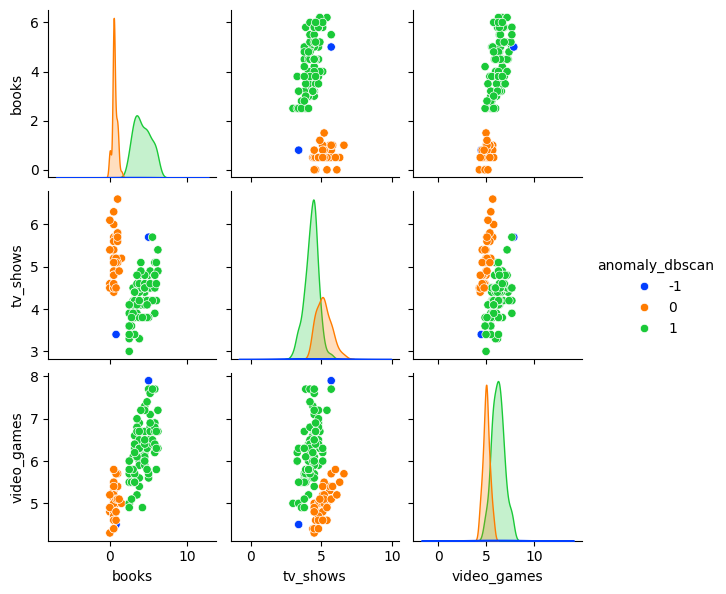

In [21]:
# create a pair plot
sns.pairplot(df[['books', 'tv_shows', 'video_games', 'anomaly_dbscan']], hue='anomaly_dbscan', palette='bright', height=2);